<a href="https://colab.research.google.com/github/bachecodes/data-science-bootcamp-selection-projects/blob/main/final-project/final__project_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = '/content/drive/MyDrive/tanzani_Train (8).csv'
df= pd.read_csv(path)
df.head()

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0
4,tour_1004,CHINA,1-24,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,7.0,4.0,Cash,Yes,No comments,1657500.0


In [3]:
df.shape

(4809, 23)

In [4]:
df.describe()

,total_female,total_male,night_mainland,night_zanzibar,total_cost
count,4806.000000,4804.000000,4809.000000,4809.000000,4.809000e+03
mean,0.926758,1.009575,8.488043,2.304429,8.114389e+06
std,1.288242,1.138865,10.427624,4.227080,1.222490e+07
min,0.000000,0.000000,0.000000,0.000000,4.900000e+04
25%,0.000000,1.000000,3.000000,0.000000,8.121750e+05
50%,1.000000,1.000000,6.000000,0.000000,3.397875e+06
75%,1.000000,1.000000,11.000000,4.000000,9.945000e+06
max,49.000000,44.000000,145.000000,61.000000,9.953288e+07


In [5]:
continous_data=['total_female','total_male','night_mainland','night_zanzibar']

categorical_cols=['travel_with','most_impressing','payment_mode','country',
                  'purpose','age_group','info_source','main_activity']

binary_cols = ['first_trip_tz','tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance',]
target_col=['total_cost',]

In [6]:
df.shape[1]== (len(continous_data)+len(categorical_cols)+len(binary_cols)+1+len(target_col))

True

In [7]:
df.isnull().sum()

,0
ID,0
country,0
age_group,0
travel_with,1114
total_female,3
total_male,5
purpose,0
main_activity,0
info_source,0
tour_arrangement,0


we have to columns with missiing values  , most impressing 313, travel_with , total_male, total_female

# filling missing values

In [13]:
# Missing indicators (before filling)
df['travel_with_missing'] = df['travel_with'].isnull().astype(int)
df['most_impressing_missing'] = df['most_impressing'].isnull().astype(int)

# Fill categorical
df['travel_with'] = df['travel_with'].fillna('Unknown')
df['most_impressing'] = df['most_impressing'].fillna('None')


    Missing here is informative
    People who didn't answer might behave differently (cost patterns change)
    This is called Missing as Information
    missing not at randiom(MNAR)

### so for cat columns
first we flag the missing to indicate as info,  and then we fill them back with data incosistencyconsistency

### and for numeric columns we fill them as aflg(0)
this may cause data inconsistency  but we will handle it later

In [14]:
# Fill numeric
df['total_female'] = df['total_female'].fillna(0)
df['total_male'] = df['total_male'].fillna(0)



## feature engineering for data analysis and consistency checkup

#### these features will help us
    **to check data consistency**
    **as well as new feature engineered to help modeling **

to basic features
                  
                  - 1 total size --> total male+total_female
                  
                  - 2total_night --> night in zanzibar+mainland

In [15]:

# for data consistency checkup
df['group_size']= df['total_female']+ df['total_male']
df['total_night']=df['night_mainland']+df['night_zanzibar']



# data inconsistency

This inconsistency usually happens because:

Possible reasons:

Data entry error

Missing numeric values recorded as 0

Survey issue (user skipped numbers but selected category)

In [26]:
# group size cannot be zero atleast 1 should exist
df[df['group_size']==0]

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost,group_size,total_night,travel_with_missing,most_impressing_missing


In [17]:
(df['group_size']==0).sum()

np.int64(17)

### fill missing by **feature extraction** methods

In [97]:
# filling alone randomly as male or female
df.loc[(df['group_size'] == 0) & (df['travel_with'] == 'Alone'),['total_female', 'total_male']] = [0, 1]

###   if they are alone , and their groupsize is greater than 1 this is also incosistent

In [27]:
df[(df['group_size'] > 1) & (df['travel_with'] == 'Alone')]

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost,group_size,total_night,travel_with_missing,most_impressing_missing


In [19]:
# two cols does not matter if we use or drop them, but there are alot of options  becouse they are two what we use not matters the most
df=df.drop(df[(df['group_size'] > 1) & (df['travel_with'] == 'Alone')].index)

In [20]:
df[(df['group_size']  > 1) & (df['travel_with'] == 'Alone')]

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost,group_size,total_night,travel_with_missing,most_impressing_missing


###   if they are with freinds or spousse , and childrens and groupsize cant be less than 1

In [28]:
df[(df['group_size'] <=1) & (((df['travel_with'] == 'Friends/Relatives') | (df['travel_with'] == 'Spouse and Children')))]

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost,group_size,total_night,travel_with_missing,most_impressing_missing


In [22]:
zero_mask=df['group_size']==0
df.loc[zero_mask, ['total_female', 'total_male']] = np.nan

mask_small = ((df['group_size'] <= 1) &(df['travel_with'].isin(['Friends/Relatives', 'Spouse and Children'])))

df.loc[mask_small, ['total_female', 'total_male']] = np.nan



In [23]:
# fill with median () values
df['total_female'] = df.groupby('travel_with')['total_female'].transform(lambda x: x.fillna(x.median()))
df['total_male'] = df.groupby('travel_with')['total_male'].transform(lambda x: x.fillna(x.median()))

In [24]:
df['group_size']= df['total_female']+ df['total_male']

In [25]:
df.isnull().sum()

,0
ID,0
country,0
age_group,0
travel_with,0
total_female,0
total_male,0
purpose,0
main_activity,0
info_source,0
tour_arrangement,0


In [29]:
df['total_night']=df['night_mainland']+df['night_zanzibar']
df[df.total_night==0]



,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost,group_size,total_night,travel_with_missing,most_impressing_missing
955,tour_2168,UNITED STATES OF AMERICA,65+,Alone,0.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,0.0,0.0,Cash,Yes,Friendly People,6298500.0,1.0,0.0,0,0
1795,tour_3184,NETHERLANDS,25-44,Unknown,0.0,1.0,Leisure and Holidays,Wildlife tourism,"Newspaper, magazines,brochures",Independent,...,0.0,0.0,Cash,Yes,Friendly People,165750.0,1.0,0.0,1,0
1914,tour_3323,CHILE,25-44,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,0.0,0.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3315000.0,2.0,0.0,0,0
2022,tour_3456,ZAMBIA,1-24,Alone,0.0,1.0,Other,Hunting tourism,"Newspaper, magazines,brochures",Independent,...,0.0,0.0,Cash,Yes,Wildlife,150000.0,1.0,0.0,0,0
2742,tour_4341,SPAIN,25-44,Alone,1.0,0.0,Visiting Friends and Relatives,Hunting tourism,Trade fair,Independent,...,0.0,0.0,Cash,No,"Wonderful Country, Landscape, Nature",828750.0,1.0,0.0,0,0
3180,tour_4852,FRANCE,25-44,Friends/Relatives,1.0,1.0,Leisure and Holidays,Conference tourism,"Friends, relatives",Package Tour,...,0.0,0.0,Cash,Yes,No comments,6795750.0,2.0,0.0,0,0
3313,tour_5007,KENYA,25-44,Unknown,0.0,1.0,Visiting Friends and Relatives,Beach tourism,others,Independent,...,0.0,0.0,Cash,No,Friendly People,1500000.0,1.0,0.0,1,0
3754,tour_5557,UNITED STATES OF AMERICA,1-24,Alone,0.0,1.0,Leisure and Holidays,Conference tourism,"Friends, relatives",Independent,...,0.0,0.0,Cash,No,Good service,3646500.0,1.0,0.0,0,0
4530,tour_655,SOUTH AFRICA,1-24,Alone,0.0,1.0,Business,Wildlife tourism,"Friends, relatives",Independent,...,0.0,0.0,Cash,Yes,No comments,1657500.0,1.0,0.0,0,0
4552,tour_687,UNITED KINGDOM,45-64,Alone,0.0,1.0,Business,Hunting tourism,"Radio, TV, Web",Independent,...,0.0,0.0,Credit Card,No,Friendly People,1657500.0,1.0,0.0,0,0


# outlier detection

In [30]:
df.total_male.value_counts()

,count
total_male,
1.0,2981
0.0,1120
2.0,479
3.0,138
4.0,46
6.0,17
5.0,15
15.0,2
7.0,2


<Axes: xlabel='total_male', ylabel='Density'>

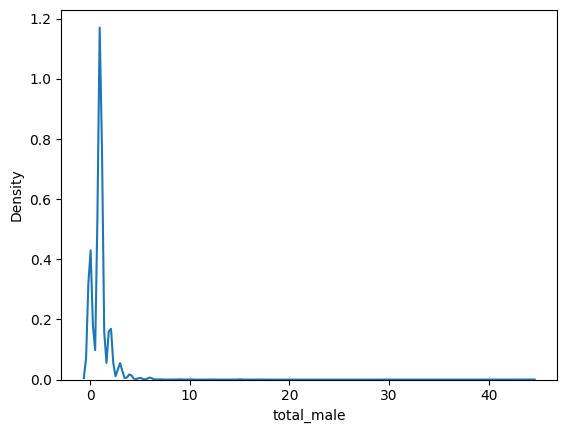

In [109]:
sns.kdeplot(df['total_male'])

<Axes: ylabel='total_male'>

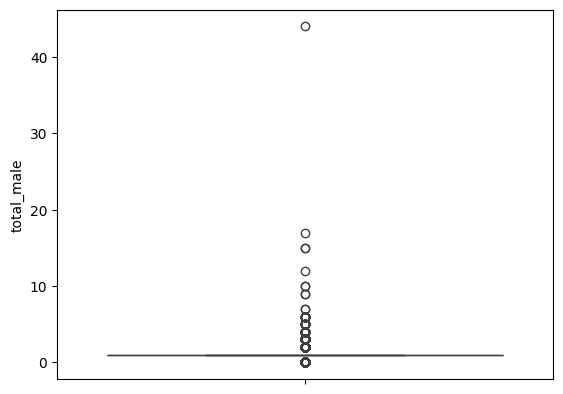

In [110]:

sns.boxplot(df['total_male'])

## as we see these outliers are not missing at random(MNAR)
so methods can be

    winsorizes--> cliping with specific percentage
    z_score --> method uses normal distribution


In [33]:
def remove_outliers( col_name,df=df):
  lower = df[col_name].quantile(0.01)
  upper = df[col_name].quantile(0.99)
  df[col_name] = np.clip(df[col_name], lower, upper)
  print(lower,upper)
  return df[col_name].value_counts()
remove_outliers('total_male')
remove_outliers('total_female')


0.0 4.0
0.0 5.0


,count
total_female,
1.0,2437
0.0,1651
2.0,464
3.0,144
5.0,65
4.0,46


In [34]:
df.total_male.value_counts()

,count
total_male,
1.0,2981
0.0,1120
2.0,479
3.0,138
4.0,89


In [35]:
df.night_mainland.value_counts()

,count
night_mainland,
0.0,536
2.0,425
7.0,414
3.0,395
4.0,379
...,...
49.0,1
75.0,1
65.0,1


In [36]:
remove_outliers('night_mainland')

0.0 59.0


,count
night_mainland,
0.0,536
2.0,425
7.0,414
3.0,395
4.0,379
6.0,356
5.0,329
10.0,326
14.0,209


In [116]:
#sns.kdeplot(df.night_mainland)

# data visualization

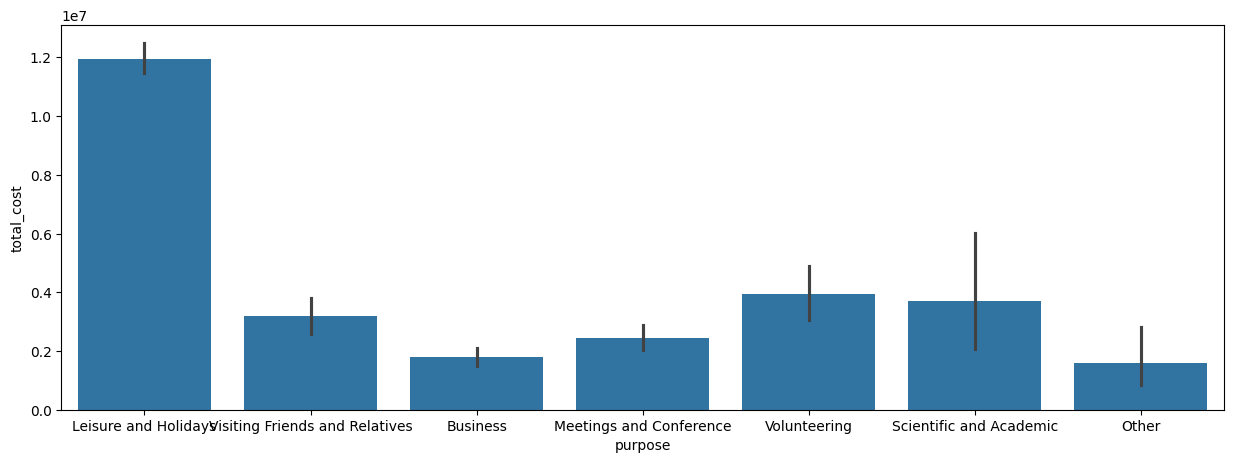

In [37]:
plt.figure(figsize=(15,5))
sns.barplot(x='purpose',y='total_cost',data=df)
plt.show()

In [30]:
plt.figure(figsize=(15,5))
sns.barplot(x='purpose',y='total_cost',data=df)
plt.show()

# EDA(explotary data analysis )

In [31]:
df.groupby('purpose')['total_cost'].count().sort_values(ascending=False)

purpose_ratio =(df.groupby('purpose')['total_cost'].count().sort_values(ascending=False))*100/4807

purpose_pct = (df.groupby('purpose')['total_cost'].sum() / df['total_cost'].sum()) * 100

purpose_pct_sorted = purpose_pct.sort_values(ascending=False)

combined_df = pd.concat([purpose_pct_sorted, purpose_ratio], axis=1)
combined_df.columns = ['Percentage of Total Cost', 'Purpose volume(frequency)',]
combined_df



,Percentage of Total Cost,Purpose volume(frequency)
purpose,,
Leisure and Holidays,87.051016,59.059705
Visiting Friends and Relatives,5.180544,13.168296
Business,3.067696,13.958810
Meetings and Conference,1.963035,6.490535
Volunteering,1.398343,2.870813
Scientific and Academic,0.816644,1.789058
Other,0.522722,2.662783


<Axes: ylabel='purpose'>

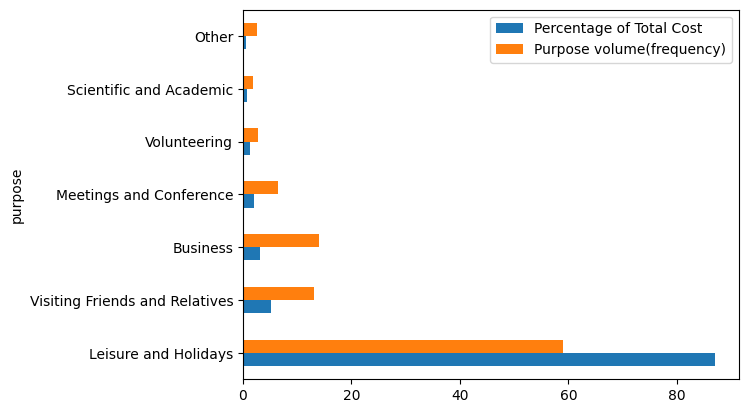

In [32]:
combined_df.plot(kind='barh')

2. Category-by-Category Interpretation
 Leisure & Holidays

59% of trips, and 87% of total cost

this is critical so features based on holiday & leisure are critical we nedd features to

    to distinguish between holiday ,
    flag to it .....


## each catagirical columns vs target

In [39]:

def cat_features_vs_target(col_name, sort_by='Cost/Volume Ratio', df=df):
    """
    Analyzes categorical features against cost.
    sort_by options: 'Percentage of Total Cost', 'Volume (Frequency %)', 'Cost/Volume Ratio'
    """
    # 1. Calculate Frequency (Volume %)
    col_name_ratio = (df.groupby(col_name)['total_cost'].count() / len(df)) * 100

    # 2. Calculate Cost Share (Total Cost %)
    col_name_pct = (df.groupby(col_name)['total_cost'].sum() / df['total_cost'].sum()) * 100

    # 3. Calculate Efficiency (Ratio)
    cost_per_volume = col_name_pct / col_name_ratio

    # 4. Combine and Rename
    combined_df = pd.concat([col_name_pct, col_name_ratio, cost_per_volume], axis=1)
    combined_df.columns = ['Percentage of Total Cost', 'Volume (Frequency %)', 'Cost/Volume Ratio']

    # 5. SORT based on the user-provided parameter
    if sort_by in combined_df.columns:
        combined_df = combined_df.sort_values(by=sort_by, ascending=False)
    else:
        print(f"Warning: {sort_by} not found. Sorting by 'Cost/Volume Ratio' instead.")
        combined_df = combined_df.sort_values(by='Cost/Volume Ratio', ascending=False)

    # 6. Visualization
    combined_df.plot(kind='bar', figsize=(15, 6), width=0.8, color=['#3498db', '#e67e22', '#2ecc71'])
    plt.title(f'Analysis of {col_name} (Sorted by {sort_by})')
    plt.ylabel('Value / Percentage')
    plt.xticks(rotation=45)
    plt.legend(loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

    return combined_df

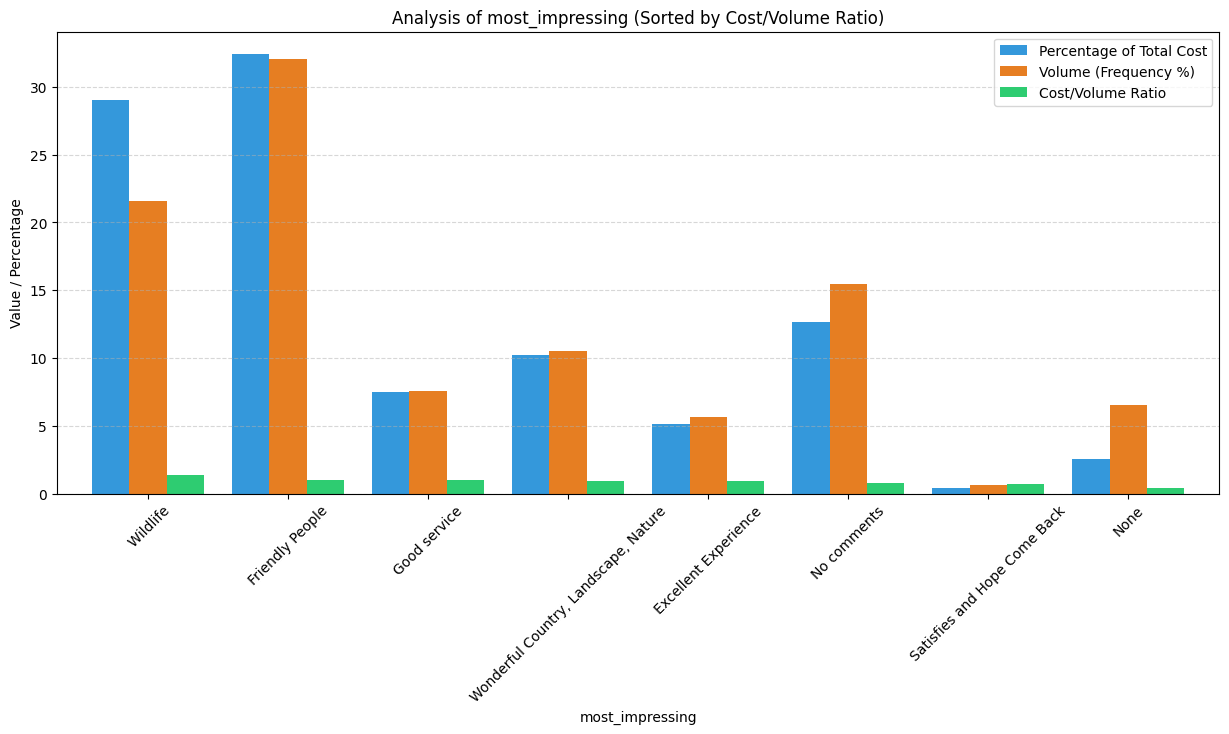

,Percentage of Total Cost,Volume (Frequency %),Cost/Volume Ratio
most_impressing,,,
Wildlife,29.062071,21.572706,1.347169
Friendly People,32.447261,32.036613,1.012818
Good service,7.462226,7.593093,0.982765
"Wonderful Country, Landscape, Nature",10.210438,10.547119,0.968078
Excellent Experience,5.165069,5.637612,0.916180
No comments,12.630730,15.456626,0.817173
Satisfies and Hope Come Back,0.450144,0.644893,0.698014
None,2.572060,6.511338,0.395013


In [40]:
cat_features_vs_target('most_impressing')

Wildlife and friendly people are the top impressions, contributing the highest shares. Service, landscape, and overall experience are rated moderately, while negative or neutral responses remain relatively low.

## Key Insights

Top drivers: Wildlife and friendly people dominate visitor impressions
Consistency: Friendly people show very stable ratings (ratio ≈ 1)
Moderate factors: Service, nature, and experience contribute steadily
Lower impact: “Satisfied/return” and “None” are minimal
Slight concern: “No comments” is relatively high → possible engagement gap

## Overall:

  Natural attractions and human interaction are the strongest strengths, while improving engagement could reduce neutral feedback.

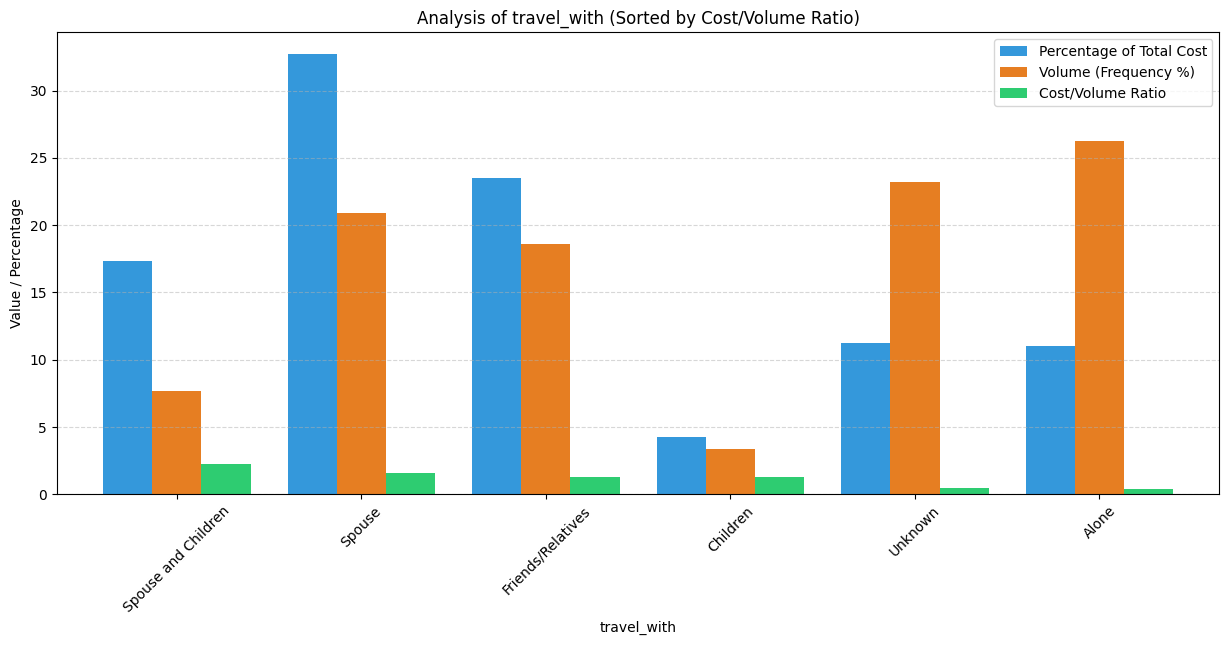

,Percentage of Total Cost,Volume (Frequency %),Cost/Volume Ratio
travel_with,,,
Spouse and Children,17.302379,7.655502,2.260123
Spouse,32.693369,20.907011,1.563752
Friends/Relatives,23.491416,18.618681,1.261712
Children,4.241116,3.370085,1.258460
Unknown,11.244024,23.174537,0.485189
Alone,11.027695,26.274183,0.419716


In [41]:
cat_features_vs_target('travel_with')

    Families = highest spending
    Couples = premium travelers
    Groups = moderate
    Solo/Unknown = budget

### Key Features, and Insights

 The dataset includes key features: *travel_with*, *Percentage of Total Cost*, *Volume (%)*, and *Cost/Volume Ratio*.  
 The *Cost/Volume Ratio* is a critical indicator of spending efficiency across different traveler groups.  
 A new feature, *Spending Category*, can be engineered by grouping the ratio into High (>1.5), Medium (1–1.5), and Low (<1).  
 The *travel_with* variable can be encoded into numerical categories (e.g., Solo=0, Couple=1, Family=2, Group=3) for machine learning models.  
 A derived feature, *Group Size Type*, can classify travelers into Solo, Couple, or Family/Group based on composition.  
 Another feature, *Revenue Contribution Score*, can be created by combining cost percentage and volume to measure overall impact.  
 A *High-Value Traveler Flag* (binary feature) can identify segments with high spending efficiency (e.g., ratio > 1.5).  
 Travelers with *spouse and children* represent the highest spending efficiency, indicating a premium segment.  
 *Couples (spouse)* contribute the largest share of total revenue, making them the core economic drivers.  
 overall, engineered features highlight that family and group travel segments generate higher revenue, while solo travelers contribute mainly to volume rather than profit.  




    

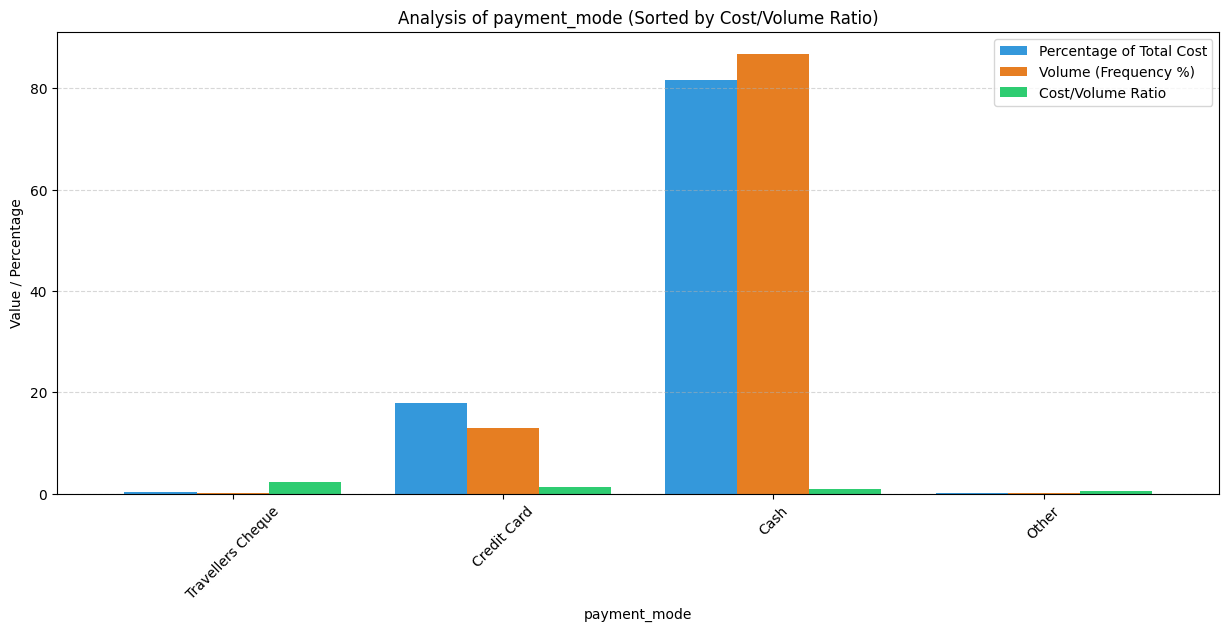

,Percentage of Total Cost,Volume (Frequency %),Cost/Volume Ratio
payment_mode,,,
Travellers Cheque,0.326783,0.145621,2.244068
Credit Card,17.908812,12.918660,1.386275
Cash,81.669844,86.769295,0.941230
Other,0.094561,0.166424,0.568192


In [42]:
cat_features_vs_target('payment_mode')

    Credit Card = premium travelers 💰
    Cash = general population ⚖️
    Cheque = rare but high-value 💎
    Other = low-value 💸

So:

Payment mode reflects financial sophistication

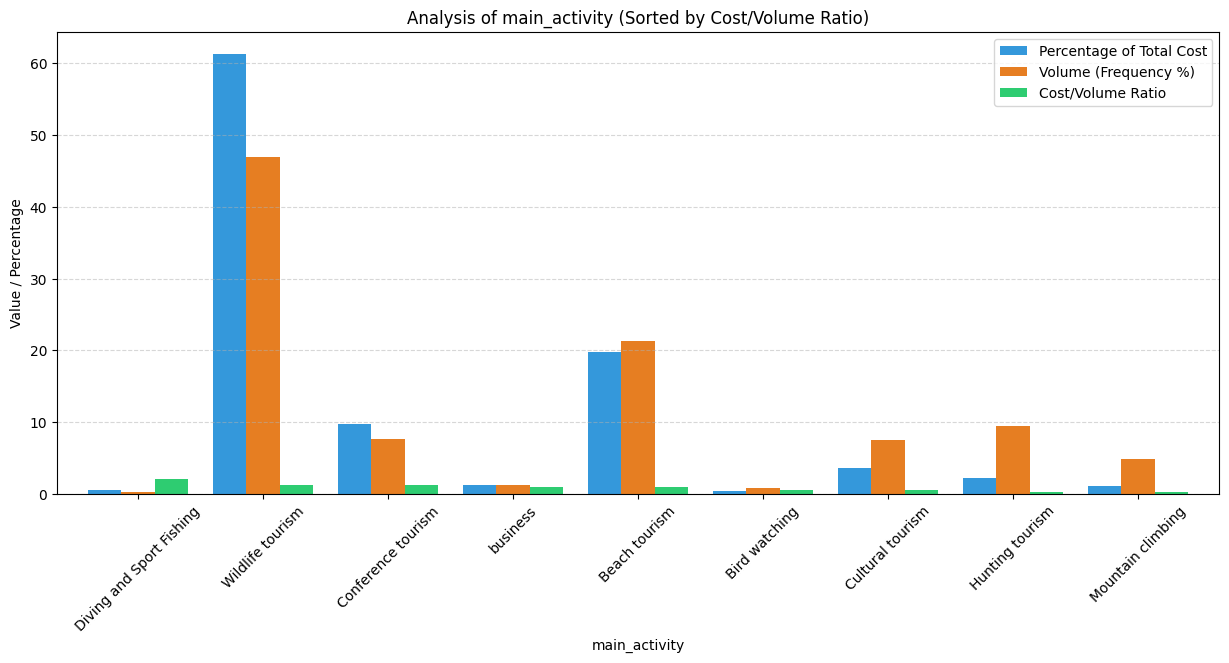

,Percentage of Total Cost,Volume (Frequency %),Cost/Volume Ratio
main_activity,,,
Diving and Sport Fishing,0.569995,0.270439,2.107666
Wildlife tourism,61.308087,46.973164,1.305173
Conference tourism,9.702093,7.634699,1.270789
business,1.202914,1.185771,1.014457
Beach tourism,19.783191,21.323071,0.927783
Bird watching,0.400162,0.769711,0.519886
Cultural tourism,3.675079,7.468275,0.492092
Hunting tourism,2.240405,9.506969,0.235659
Mountain climbing,1.118074,4.867901,0.229683


In [43]:
cat_features_vs_target('main_activity')

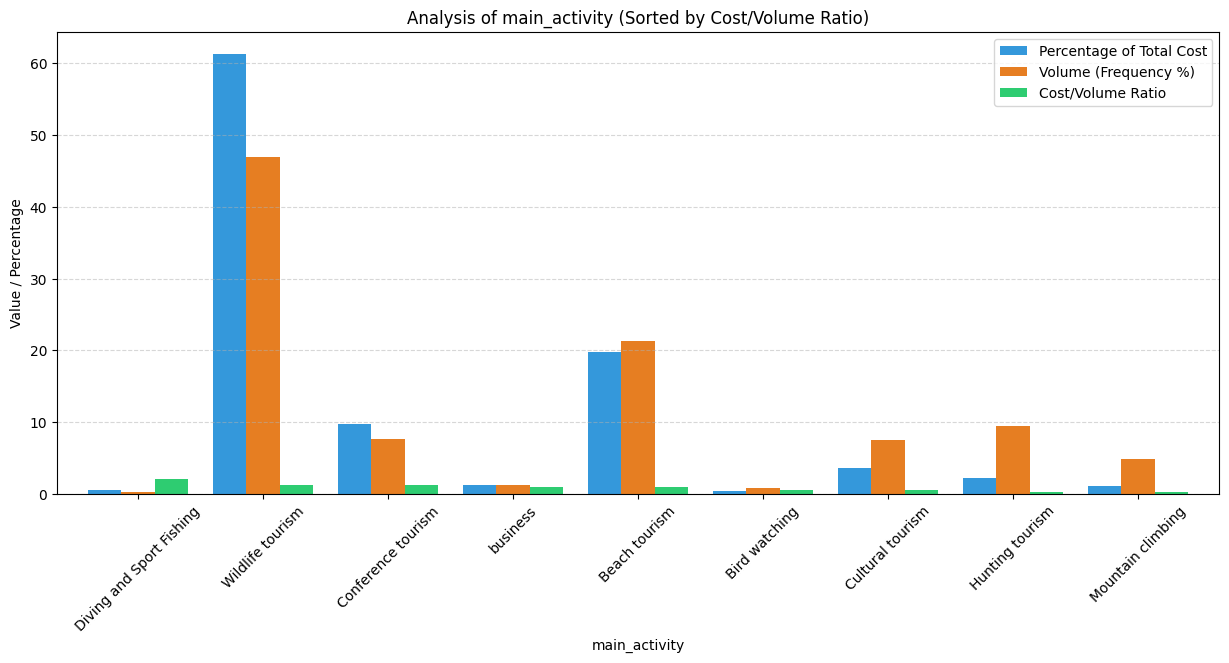

,Percentage of Total Cost,Volume (Frequency %),Cost/Volume Ratio
main_activity,,,
Diving and Sport Fishing,0.569995,0.270439,2.107666
Wildlife tourism,61.308087,46.973164,1.305173
Conference tourism,9.702093,7.634699,1.270789
business,1.202914,1.185771,1.014457
Beach tourism,19.783191,21.323071,0.927783
Bird watching,0.400162,0.769711,0.519886
Cultural tourism,3.675079,7.468275,0.492092
Hunting tourism,2.240405,9.506969,0.235659
Mountain climbing,1.118074,4.867901,0.229683


In [39]:
cat_features_vs_target('main_activity')

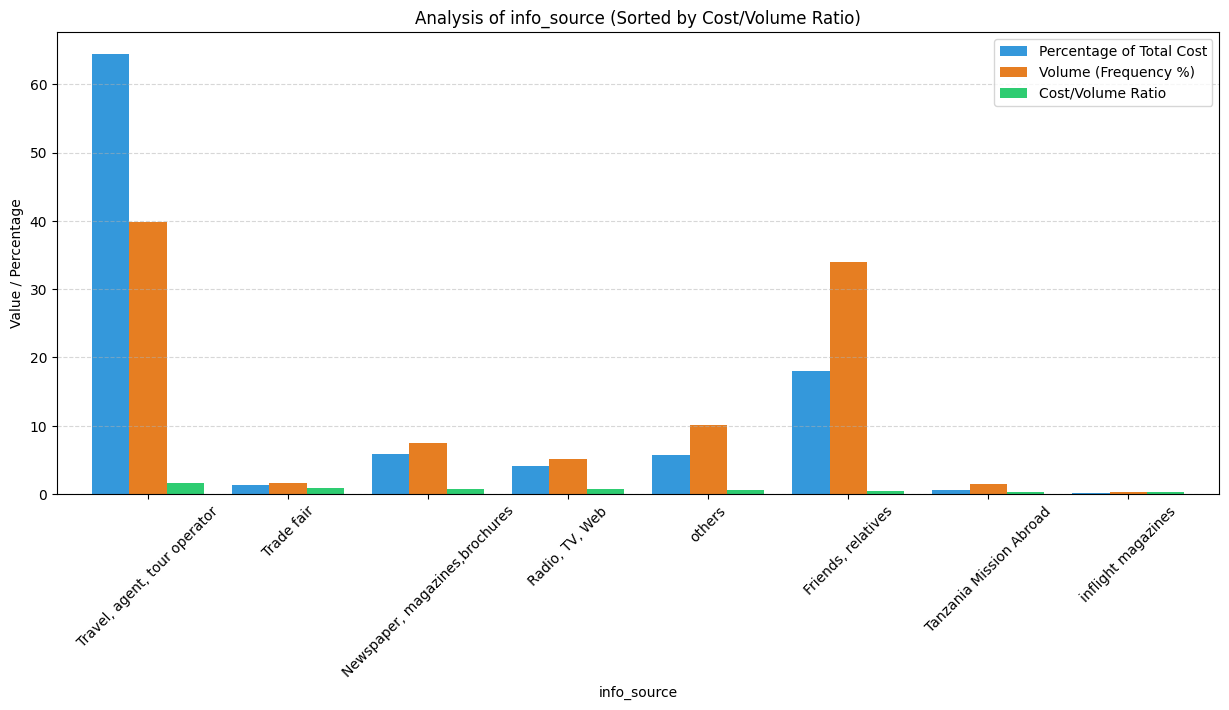

,Percentage of Total Cost,Volume (Frequency %),Cost/Volume Ratio
info_source,,,
"Travel, agent, tour operator",64.392078,39.796131,1.618049
Trade fair,1.333457,1.601831,0.832458
"Newspaper, magazines,brochures",5.880597,7.468275,0.787410
"Radio, TV, Web",4.056516,5.179946,0.783119
others,5.686804,10.193468,0.557887
"Friends, relatives",17.987224,33.971292,0.529483
Tanzania Mission Abroad,0.548148,1.414604,0.387492
inflight magazines,0.115176,0.374454,0.307583


In [40]:


cat_features_vs_target('info_source')

    Travel agents = organized, high-spending tourists 💰
    Friends = informal, budget travelers 💸
    Media = independent, mid-level ⚖️

👉 So:

This feature captures trip planning sophistication

## two columns vs target

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

def dual_cat_vs_target(col1, col2, sort_by=None, df=df):
    """
    Analyzes the interaction between two categories vs cost.
    """
    # 1. Group by BOTH columns
    group_cols = [col1, col2]

    # 2. Calculate Frequency (Volume %)
    # What % of all trips are this specific combo?
    vol_pct = (df.groupby(group_cols)['total_cost'].count() / len(df)) * 100

    # 3. Calculate Cost Share (Total Cost %)
    # What % of all money was spent by this specific combo?
    cost_pct = (df.groupby(group_cols)['total_cost'].sum() / df['total_cost'].sum()) * 100

    # 4. Calculate the Impact Ratio
    impact_ratio = cost_pct / vol_pct

    # 5. Combine with Dynamic Column Names
    combined_df = pd.concat([cost_pct, vol_pct, impact_ratio], axis=1)

    # Naming columns based on the two inputs
    c_name = f"{col1}_{col2}_cost_pct"
    v_name = f"{col1}_{col2}_vol_pct"
    r_name = f"{col1}_{col2}_ratio"
    combined_df.columns = [c_name, v_name, r_name]

    # 6. Sorting (Default to the ratio/efficiency)
    if sort_by is None:
        sort_by = r_name
    combined_df = combined_df.sort_values(by=sort_by, ascending=False)

    # 7. Visualization
    # We take the top 15 combinations so the chart stays readable
    combined_df.head(15).plot(kind='bar', figsize=(15, 7), width=0.8)
    plt.title(f'Top 15 Combinations: {col1} & {col2} (Sorted by {sort_by})')
    plt.ylabel('Percentage / Ratio')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    return combined_df

# Example call:
# dual_cat_vs_target('age_group', 'purpose')

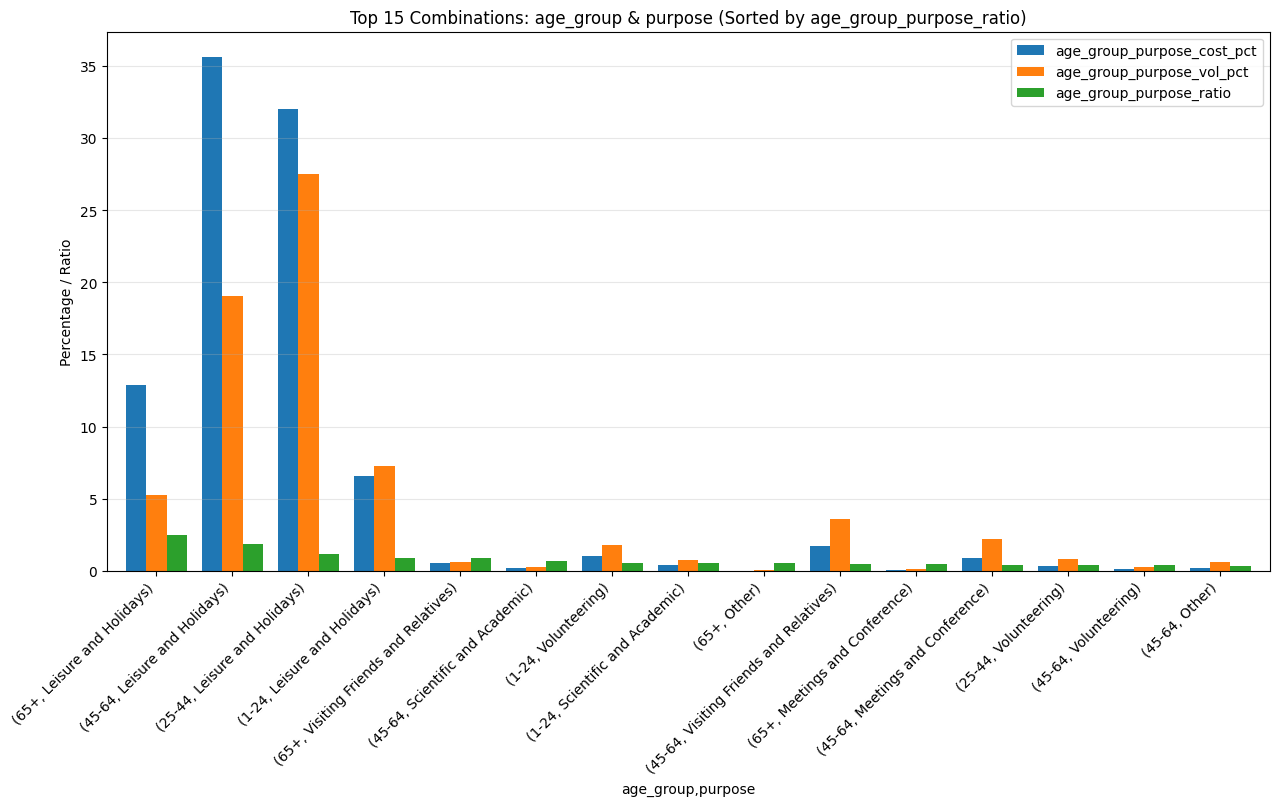

age_group_purpose_cost_pct  \
age_group purpose                                                      
65+       Leisure and Holidays                             12.852444   
45-64     Leisure and Holidays                             35.617943   
25-44     Leisure and Holidays                             32.003084   
1-24      Leisure and Holidays                              6.577545   
65+       Visiting Friends and Relatives                    0.510681   
45-64     Scientific and Academic                           0.155076   
1-24      Volunteering                                      0.986606   
          Scientific and Academic                           0.416818   
65+       Other                                             0.010628   
45-64     Visiting Friends and Relatives                    1.723970   
65+       Meetings and Conference                           0.064633   
45-64     Meetings and Conference                           0.904379   
25-44     Volunteering                                      0.309647   
45-64     Volunteering                                      0.101240   
          Other                                             0.206214   
25-44     Visiting Friends and Relatives                    2.470101   
          Scientific and Academic                           0.225629   
65+       Scientific and Academic                           0.019121   
          Business                                          0.094904   
1-24      Other                                             0.073572   
25-44     Meetings and Conference                           0.963575   
1-24      Visiting Friends and Relatives                    0.475792   
25-44     Business                                          2.230686   
45-64     Business                                          0.635766   
1-24      Meetings and Conference                           0.030449   
          Business                                          0.106341   
25-44     Other                                             0.232308   
65+       Volunteering                                      0.000850   

                                          age_group_purpose_vol_pct  \
age_group purpose                                                     
65+       Leisure and Holidays                             5.242355   
45-64     Leisure and Holidays                            19.034741   
25-44     Leisure and Holidays                            27.522363   
1-24      Leisure and Holidays                             7.260245   
65+       Visiting Friends and Relatives                   0.582484   
45-64     Scientific and Academic                          0.228833   
1-24      Volunteering                                     1.768255   
          Scientific and Academic                          0.769711   
65+       Other                                            0.020803   
45-64     Visiting Friends and Relatives                   3.557312   
65+       Meetings and Conference                          0.145621   
45-64     Meetings and Conference                          2.205118   
25-44     Volunteering                                     0.811317   
45-64     Volunteering                                     0.270439   
          Other                                            0.582484   
25-44     Visiting Friends and Relatives                   7.031413   
          Scientific and Academic                          0.728105   
65+       Scientific and Academic                          0.062409   
          Business                                         0.312045   
1-24      Other                                            0.249636   
25-44     Meetings and Conference                          3.952569   
1-24      Visiting Friends and Relatives                   1.997088   
25-44     Business                                         9.860620   
45-64     Business                                         3.037237   
1-24      Meetings and Conference  

In [44]:
dual_cat_vs_target('age_group', 'purpose')

### using aggregate

In [68]:
# Compare different statistics
df.groupby(['main_activity', 'age_group'])['total_cost'].agg(['mean', 'median', 'count', 'std'])

mean       median  count  \
main_activity            age_group                                     
Beach tourism            1-24       3.349281e+06   1792037.50    138   
                         25-44      7.120587e+06   3646500.00    625   
                         45-64      1.071199e+07   6630000.00    240   
                         65+        1.043245e+07   5794359.00     22   
Bird watching            1-24       3.996912e+06   3996912.50      2   
                         25-44      1.396917e+06    548632.50     22   
                         45-64      4.576570e+06    745875.00     10   
                         65+        2.384038e+07   4060875.00      3   
Conference tourism       1-24       9.544301e+06   5138250.00     83   
                         25-44      9.280695e+06   6062306.25    198   
                         45-64      1.311966e+07   8453250.00     79   
                         65+        1.662709e+07  18066750.00      7   
Cultural tourism         1-24       3.909416e+06   2420000.00    107   
                         25-44      3.470817e+06   1530838.25    166   
                         45-64      4.968687e+06   1433730.00     73   
                         65+        5.818596e+06   5386875.00     13   
Diving and Sport Fishing 25-44      1.812566e+07   4309500.00      6   
                         45-64      7.566488e+06   2817750.00      4   
                         65+        2.773550e+07  27017250.00      3   
Hunting tourism          1-24       2.456588e+06    522327.00     82   
                         25-44      1.372646e+06    497250.00    242   
                         45-64      2.390379e+06    596700.00    125   
                         65+        5.132328e+06    985950.00      8   
Mountain climbing        1-24       1.112691e+06    473502.50      4   
                         25-44      1.880210e+06    828750.00    149   
                         45-64      1.857079e+06    828750.00     73   
                         65+        1.967462e+06   1044225.00      8   
Wildlife tourism         1-24       7.262053e+06   3273562.50    199   
                         25-44      6.831747e+06   3008325.00   1052   
                         45-64      1.390353e+07   9090740.00    766   
                         65+        1.917094e+07  16740750.00    241   
business                 1-24       5.263297e+06   4538660.00      9   
                         25-44      6.996716e+06   5055375.00     26   
                         45-64      1.044498e+07   4218839.00     20   
                         65+        1.540061e+07  15400612.50      2   

                                             std  
main_activity            age_group                
Beach tourism            1-24       3.673453e+06  
                         25-44      1.014240e+07  
                         45-64      1.361191e+07  
                         65+        1.385176e+07  
Bird watching            1-24       2.370805e+06  
                         25-44      2.553133e+06  
                         45-64      7.317869e+06  
                         65+        3.738777e+07  
Conference tourism       1-24       1.749110e+07  
                         25-44      1.138560e+07  
                         45-64      1.327424e+07  
                         65+        1.311428e+07  
Cultural tourism         1-24       5.123929e+06  
                         25-44      6.915873e+06  
                         45-64      7.768721e+06  
                         65+        5.260186e+06  
Diving and Sport Fishing 25-44      3.208725e+07  
                         45-64      1.078907e+07  
                         65+        2.495313e+07  
Hunting tourism          1-24       8.583267e+06  
                         25-44      3.286848e+06  
                         45-64      6.038951e+06  
                         65+        1.136484e+07  
Mountain climbing        1-24       1.491008e+06  
                         25-44      3.936798e+06  
  

<Axes: xlabel='main_activity', ylabel='total_cost'>

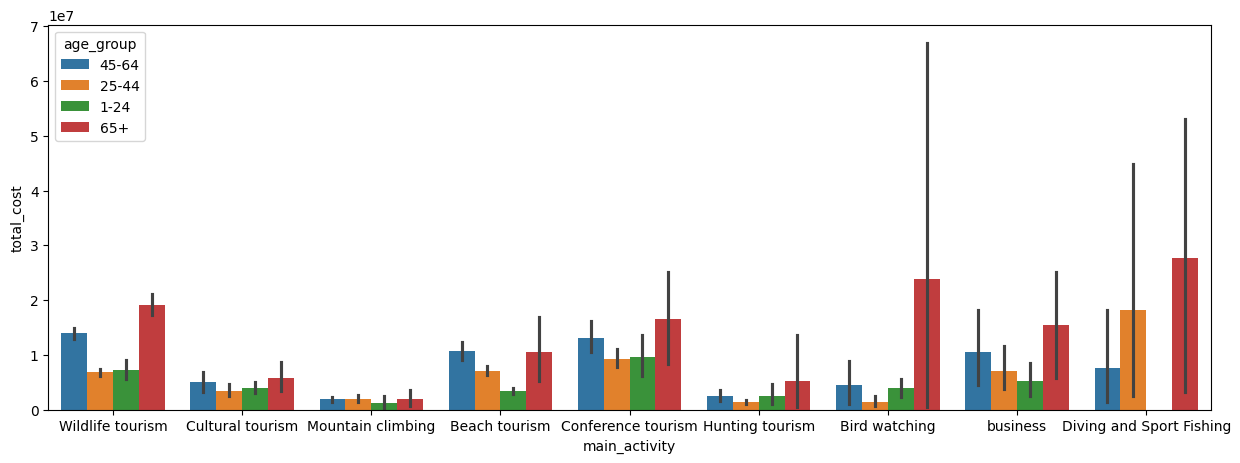

In [64]:
plt.figure(figsize=(15,5))
sns.barplot(x=df['main_activity'] ,y=df['total_cost'],hue='age_group',data=df,)

##  what we see

Tourism activity generally increases with age, with people aged **25–64 and 65+** driving most participation. **Beach, conference, wildlife, and business tourism** are the most popular across all groups. Older travelers prefer more relaxed or experience-based activities like **bird watching and diving**, while **mountain climbing and hunting** remain niche with low participation.

###  Key Insights

* Demand **peaks in middle-aged and older groups**
* **Beach & conference tourism dominate overall**
* **Older groups favor specialized leisure activities**
* **Younger group participation is relatively low**
* Some missing data (e.g., diving for youngest group) may affect analysis


In [ ]:
cata

In [69]:
# Compare different statistics
df.groupby(['travel_with', 'age_group'])['total_cost'].agg(['mean', 'median', 'count', 'std'])

mean       median  count           std
travel_with         age_group                                                
Alone               1-24       3.948009e+06   2071875.00    234  9.309394e+06
                    25-44      2.230341e+06    994500.00    696  3.143585e+06
                    45-64      4.369222e+06   1657500.00    274  7.900435e+06
                    65+        1.061182e+07   7723950.00     59  1.055847e+07
Children            1-24       3.433385e+06   3637638.00      4  2.156542e+06
                    25-44      6.450696e+06   2817750.00     61  8.739651e+06
                    45-64      1.256421e+07  10442250.00     87  1.199164e+07
                    65+        1.531898e+07  16575000.00     10  9.986757e+06
Friends/Relatives   1-24       9.011617e+06   4011150.00    154  1.509125e+07
                    25-44      8.717945e+06   4475250.00    499  1.321378e+07
                    45-64      1.324122e+07   7375875.00    200  1.574702e+07
                    65+        1.839077e+07  10001387.50     42  1.849451e+07
Spouse              1-24       5.472071e+06   5022225.00     41  4.517055e+06
                    25-44      9.780772e+06   7458750.00    487  1.024691e+07
                    45-64      1.399015e+07   9655606.25    332  1.443250e+07
                    65+        2.147575e+07  19110975.00    145  1.600986e+07
Spouse and Children 1-24       1.985278e+07  13260000.00     12  1.768869e+07
                    25-44      1.525042e+07  10276500.00    130  1.732263e+07
                    45-64      2.004551e+07  17246908.00    219  1.633688e+07
                    65+        1.928564e+07  18066750.00      7  1.968400e+07
Unknown             1-24       3.302476e+06   1300000.00    179  5.820496e+06
                    25-44      3.169619e+06   1243125.00    613  6.189046e+06
                    45-64      4.914570e+06   1657500.00    278  8.678045e+06
                    65+        1.098605e+07   5801250.00     44  1.286535e+07

<Axes: xlabel='travel_with', ylabel='total_cost'>

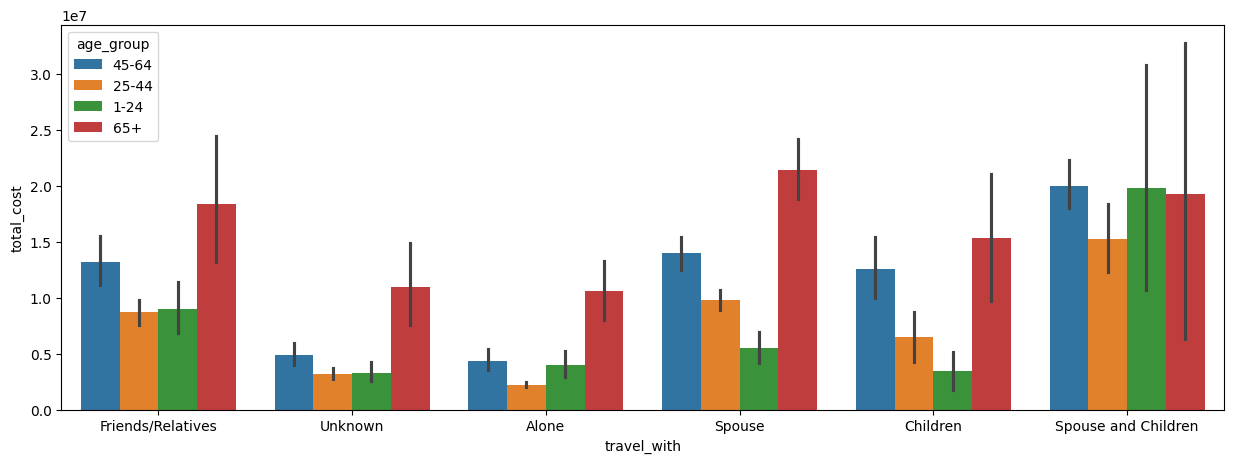

In [70]:
plt.figure(figsize=(15,5))
sns.barplot(x=df['travel_with'] ,y=df['total_cost'],hue='age_group',data=df,)

## Key Insights

- Spending increases significantly with **age**, especially after 45.
- **Solo travelers** are the lowest spenders → budget segment.
- **Spouse & family travelers** are the highest spenders → premium segment.
- Traveling with **more companions = higher total cost**.
- **65+ travelers** consistently show the highest spending across all groups.
- **Friends/Relatives** group shows high spending but with strong variability.
- Large gap between **mean and median** → data is highly **right-skewed** (few luxury spenders).
- High **standard deviation** → presence of outliers and diverse spending behavior.
- **25–44 group** has the largest sample → most reliable segment.
- Very small groups (e.g., children 1–24) are **not statistically reliable**.

### Feature Engineering Ideas
- `is_family_trip` (Spouse / Spouse+Children)
- `group_size_category` (Alone, Small group, Family)
- `high_spender_flag` (based on percentile)
- `cost_per_person` (total_cost / group_size)

In [ ]:
# Compare different statistics
df.groupby(['travel_with', 'age_group'])['total_cost'].agg(['mean', 'median', 'count', 'std'])

<Axes: xlabel='travel_with', ylabel='total_cost'>

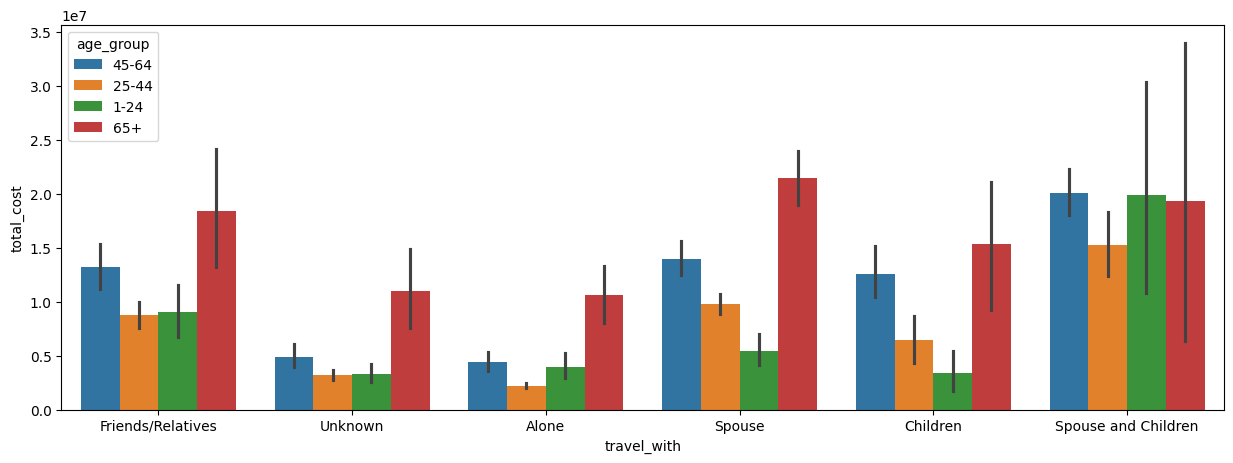

In [81]:
plt.figure(figsize=(15,5))
sns.barplot(x=df['travel_with'] ,y=df['total_cost'],hue='age_group',data=df,)

## crosstab analysis

In [78]:
pd.crosstab(df['purpose'],df['age_group'])

age_group,1-24,25-44,45-64,65+
purpose,,,,
Business,36,474,146,15
Leisure and Holidays,349,1323,915,252
Meetings and Conference,9,190,106,7
Other,12,87,28,1
Scientific and Academic,37,35,11,3
Visiting Friends and Relatives,96,338,171,28
Volunteering,85,39,13,1


In [74]:
pd.crosstab(df['main_activity'],df['age_group'])

age_group,1-24,25-44,45-64,65+
main_activity,,,,
Beach tourism,138,625,240,22
Bird watching,2,22,10,3
Conference tourism,83,198,79,7
Cultural tourism,107,166,73,13
Diving and Sport Fishing,0,6,4,3
Hunting tourism,82,242,125,8
Mountain climbing,4,149,73,8
Wildlife tourism,199,1052,766,241
business,9,26,20,2


## Key Insights (Main Activity vs Age Group)

- **Wildlife tourism** is the most dominant across all ages, especially **25–44 and 45–64**.
- **Beach tourism** is the second most popular, mainly driven by **25–44**.
- **25–44 age group** is the most active across almost all activities → core target segment.
- **45–64 group** shows strong interest in **wildlife, hunting, and beach tourism**.
- **65+ travelers** prefer **wildlife tourism**, with very low participation in other activities.
- **Young travelers (1–24)** are mostly engaged in **wildlife, beach, and cultural tourism**.
- **Hunting tourism** has notable participation in **25–64**, but low in younger/older groups.
- **Mountain climbing** is mainly preferred by **25–44 and 45–64**.
- **Conference & business tourism** are concentrated in **25–44 and 45–64** (working-age group).
- Niche activities like **bird watching, diving** have very low participation overall.

### Feature Engineering Ideas

- `activity_popularity_score` (based on total counts)
- `age_activity_preference` (dominant activity per age group)
- `is_nature_activity` (wildlife, mountain, bird watching)
- `is_leisure_activity` (beach, cultural)
- `is_business_activity` (conference, business)
- `high_demand_activity_flag` (e.g., wildlife, beach)
- `niche_activity_flag` (low-frequency activities)

In [80]:
pd.crosstab(df['travel_with'],df['main_activity'])

main_activity,Beach tourism,Bird watching,Conference tourism,Cultural tourism,Diving and Sport Fishing,Hunting tourism,Mountain climbing,Wildlife tourism,business
travel_with,,,,,,,,,
Alone,207,15,112,83,3,208,96,526,13
Children,33,3,14,18,2,18,1,71,2
Friends/Relatives,220,5,91,72,5,59,41,392,10
Spouse,288,5,47,51,1,25,6,562,20
Spouse and Children,121,0,9,12,0,9,3,210,4
Unknown,156,9,94,123,2,138,87,497,8


## Key Insights (Travel Companion vs Activity)

- **Wildlife tourism** dominates across all travel groups → universal top activity.
- **Spouse travelers** show the highest engagement in **wildlife and beach tourism**.
- **Alone travelers** prefer **wildlife, hunting, and beach tourism**.
- **Friends/Relatives groups** are highly active in **beach, wildlife, and conference tourism**.
- **Family trips (Spouse & Children)** focus mainly on **wildlife and beach**, less on niche activities.
- **Children group** has low participation overall → limited influence.
- **Conference tourism** is strongest among **Alone, Friends, and Unknown** groups.
- **Hunting tourism** is more popular among **Alone and Unknown** travelers.
- **Mountain climbing** is mostly chosen by **Alone and Unknown** groups.
- **Business tourism** is low across all categories → niche segment.

### Feature Engineering Ideas

- `companion_type` (Solo, Couple, Family, Group)
- `is_family_trip` (Children / Spouse & Children)


In [79]:
pd.crosstab(df['travel_with'],df['age_group'])

age_group,1-24,25-44,45-64,65+
travel_with,,,,
Alone,234,696,274,59
Children,4,61,87,10
Friends/Relatives,154,499,200,42
Spouse,41,487,332,145
Spouse and Children,12,130,219,7
Unknown,179,613,278,44


Quick Summary (Counts)

Most travelers are in the 25–44 age group across all travel types. Traveling alone and with friends/relatives are the most common patterns, especially among younger and middle-aged groups.

 Key Insights
25–44 dominates in all categories
Solo travel is the most frequent overall
Friends/relatives travel is also very common
Spouse travel increases with age (peaks in 45–64 & 65+)
Family travel (spouse & children) is moderate, highest in 45–64
Very few travel only with children, especially in younger ages

 Overall: Middle-aged travelers are the most active, with a shift from solo/friends travel to spouse/family travel as age increases.

# numerical correlation analysis

<Axes: >

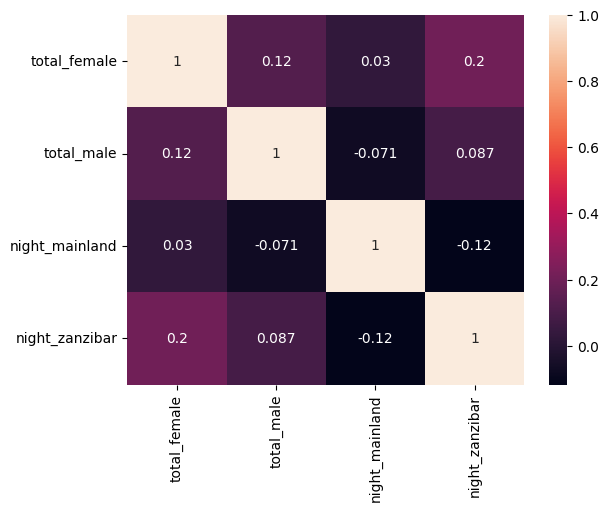

In [127]:
sns.heatmap(df[continous_data].corr(),annot=True)

In [129]:
df[continous_data].corr()

,total_female,total_male,night_mainland,night_zanzibar
total_female,1.000000,0.123689,0.029768,0.202793
total_male,0.123689,1.000000,-0.070773,0.087022
night_mainland,0.029768,-0.070773,1.000000,-0.117814
night_zanzibar,0.202793,0.087022,-0.117814,1.000000


verall, correlations are weak, meaning these variables are mostly independent.

 Key Insights

Female vs Zanzibar nights: weak positive correlation (~0.20) females slightly more associated with Zanzibar stays
Male vs Mainland nights: weak negative correlation (~-0.07) → almost no real relationship
Mainland vs Zanzibar nights: slight negative (~-0.12) → travelers tend to choose one over the other
Gender relationship: very low correlation between male and female counts → expected separation

 Overall:

  No strong relationships, but a small tendency for female travelers to stay more in Zanzibar, while mainland and Zanzibar visits slightly substitute each other.

# feature engineering




In [122]:

# =========================
# 1. GROUP SIZE (core behavior)
# =========================
df['group_size'] = df['total_female'] + df['total_male']  # total number of travelers in group



In [123]:

# =========================

#  IS LEISURE (strong cost driver)
# =========================
df['is_leisure'] = (df['purpose'] == 'Leisure & Holidays').astype(int)
# leisure trips are highest spending segment



In [124]:
# =========================
#  IS FAMILY TRAVEL (strong multiplier effect)
# =========================
df['is_family'] = df['travel_with'].isin(['Spouse', 'Spouse and Children']).astype(int)
# family trips increase total cost significantly



In [130]:
df['spend_per_night']=df['total_cost']/df['total_night']

In [131]:
df['cost_per_person']=df['total_cost']/df['group_size']

In [125]:
# =========================
#  LEISURE + FAMILY INTERACTION
# =========================
df['leisure_family'] = (
    (df['purpose'] == 'Leisure & Holidays') &
    (df['travel_with'].isin(['Spouse', 'Spouse and Children']))
).astype(int)

# Tanzania Tourism Dataset — Data Analysis Summary

## 1. Overview of the Dataset

This dataset contains structured information about tourists visiting Tanzania. It includes demographic attributes, travel behavior, financial behavior, trip characteristics, and feedback indicators.

The primary variable of interest is **total cost**, which reflects the expenditure of tourists during their visit.

The dataset can be broadly grouped into the following categories:

- **Demographic information:** age group, country  
- **Travel behavior:** purpose of visit, travel companions, main activity, number of nights  
- **Financial behavior:** payment method, package usage (transport, accommodation, food, etc.)  
- **Information source:** how tourists learned about or planned their trip  
- **Experience feedback:** most impressive aspect of the visit  
- **Target variable:** total cost  

---

## 2. Key Insights from the Data

### 2.1 Travel Purpose and Spending Behavior

- Leisure and holiday travel accounts for the largest share of total expenditure.
- Business and visiting friends/relatives are frequent purposes but contribute relatively low spending per trip.
- Academic and scientific travel is rare and associated with low expenditure.

**Conclusion:**  
Travel purpose is a strong indicator of spending behavior, with leisure-oriented travel generating significantly higher costs.

---

### 2.2 Age Group and Spending Patterns

- Tourists aged 45–64 and 65+ contribute the highest average spending per trip.
- The 25–44 age group represents the highest frequency of travelers but with moderate spending levels.
- The 1–24 age group contributes the lowest spending.

**Conclusion:**  
Older age groups tend to spend more per trip, while younger groups travel more frequently but spend less.

---

### 2.3 Travel Companions and Group Structure

- Travelers accompanied by a spouse or spouse with children tend to generate the highest total expenditure.
- Solo travelers represent a large proportion of visits but contribute relatively lower spending.
- Travelers with friends or relatives fall into a moderate spending category.
- Missing or unknown group information is associated with lower spending patterns.

**Conclusion:**  
Group composition significantly influences total expenditure, with family-based travel showing higher costs.

---

### 2.4 Experience Feedback (Most Impressive Aspect)

- Wildlife experiences are strongly associated with higher spending.
- Positive general feedback such as friendly people or natural scenery represents moderate spending behavior.
- Missing or neutral responses (e.g., “no comments” or “none”) are associated with lower expenditure.

**Conclusion:**  
The type of experience reported reflects the level of engagement and is linked to spending intensity.

---

### 2.5 Payment Methods and Financial Behavior

- Credit card users tend to spend more compared to cash users.
- Cash is the most commonly used payment method but is associated with average or lower spending.
- Travelers’ cheque users, although rare, represent a high-spending group.

**Conclusion:**  
Payment method reflects financial behavior and is a useful indicator of spending capacity.

---

### 2.6 Information Sources and Trip Planning Behavior

- Travel agents and tour operators are associated with the highest spending levels.
- Friends and relatives as information sources are associated with lower spending.
- Media sources such as newspapers, television, and online platforms represent moderate spending behavior.
- Less formal or unspecified sources tend to correspond with lower expenditure.

**Conclusion:**  
The method used to obtain travel information reflects the level of trip organization and spending behavior.

---

## 3. Overall Behavioral Patterns

The dataset reveals clear and consistent behavioral patterns among tourists:

- High spending is generally associated with:
  - Leisure travel
  - Older age groups
  - Family or spouse-based travel
  - Wildlife-related experiences
  - Use of credit-based payment methods
  - Organized travel through agents

- Lower spending is generally associated with:
  - Business or visiting purposes
  - Younger age groups
  - Solo travel
  - Informal planning sources
  - Lack of detailed experience feedback

---

## 4. General Conclusion

Tourist expenditure in this dataset is strongly influenced by behavioral, demographic, and trip-related factors. Spending patterns are not random but instead follow structured relationships between travel purpose, age, group composition, planning method, and experience type.

These variables collectively describe the socio-economic and behavioral profile of tourists, which directly impacts their level of expenditure during travel.